# Exploratory Data Analysis (EDA)

El objetivo de este notebook es explorar, comprender y preparar el dataset bancario para su posterior utilización en una aplicación interactiva desarrollada con Streamlit.

Durante este proceso se analizará la estructura de los datos, la calidad de las variables, la presencia de valores faltantes, posibles inconsistencias y la relación entre las distintas variables disponibles.

## 1. Definición del problema

La institución bancaria dispone de un conjunto de datos relacionados con clientes, productos financieros y comportamiento dentro de la aplicación móvil.

El objetivo es explorar, comprender y preparar los datos para construir posteriormente una aplicación interactiva en Streamlit que permita analizar la información mediante filtros y visualizaciones dinámicas.

Durante este proceso se identificarán problemas de calidad de datos, patrones descriptivos y posibles relaciones entre las variables disponibles.

## 2. Recopilación de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv(
    "../data/raw/p4ds-dataset-bancario.csv",
    sep=";"
)

In [22]:
df.head()

,Fecha,Número ID,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora
0,23/05/2025,1,Durazno,Premier,NaN,NaN,Registrado,24/05/2025,Cobrado
1,14/05/2025,2,Canelones,Préstamo Consumo,"672,0",C2,No Registrado,NaN,Cobrado
2,10/10/2025,3,Montevideo,Tarjeta de Crédito,NaN,NaN,No Registrado,NaN,En Mora
3,15/12/2025,4,Montevideo,Premier,NaN,NaN,Registrado,21/12/2025,Cobrado
4,30/12/2025,5,Montevideo,Préstamo Automotor,"20053,0",M1,Registrado,31/12/2025,Incobrable


In [8]:
df.shape,
df.columns,
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Fecha                     550 non-null    str  
 1   Número ID                 550 non-null    int64
 2   Sucursal                  550 non-null    str  
 3   Producto                  550 non-null    str  
 4   Monto USD                 225 non-null    str  
 5   Vendedor                  225 non-null    str  
 6   Estado App                550 non-null    str  
 7   Fecha Registro en la App  301 non-null    str  
 8   estado_mora               550 non-null    str  
dtypes: int64(1), str(8)
memory usage: 72.4 KB



El conjunto de datos contiene 550 registros y 9 variables.

Se observan variables categóricas, numéricas y temporales, lo que permitirá realizar distintos tipos de análisis descriptivos.

También se detecta la presencia de valores faltantes en algunas columnas, aspecto que será evaluado en las siguientes etapas.

## 3. Análisis Descriptivo

In [5]:
df.describe(include="all")

,Fecha,Número ID,Sucursal,Producto,Monto USD,Vendedor,Estado App,Fecha Registro en la App,estado_mora
count,550,550.000000,550,550,225,225,550,301,550
unique,228,NaN,19,6,221,51,2,213,3
top,14/02/2025,NaN,Montevideo,Cuenta Sueldo,"586,0",M2,Registrado,31/01/2025,Cobrado
freq,8,NaN,127,157,2,21,301,4,396
mean,NaN,275.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,158.915596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,138.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,275.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,412.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


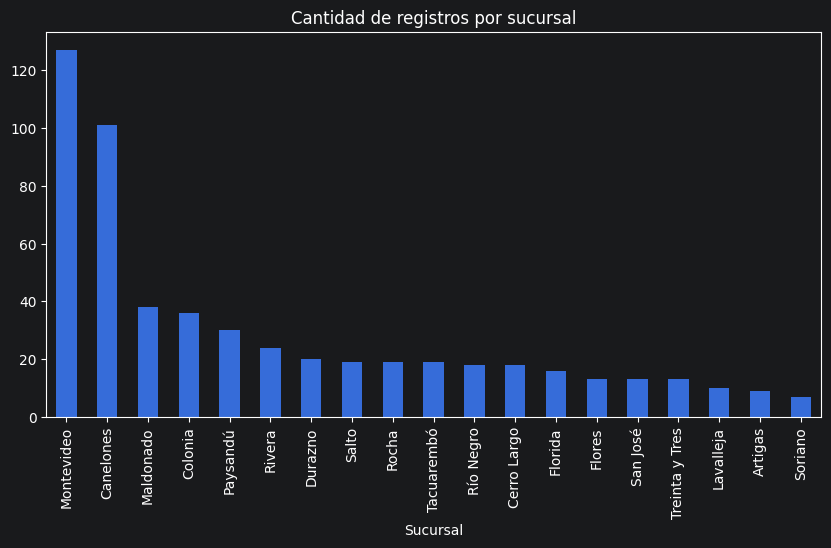

In [6]:
df["Sucursal"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Cantidad de registros por sucursal")
plt.show()

In [4]:
px.bar(
    df["Producto"]
    .value_counts()
    .reset_index(),
    x="Producto",
    y="count",
    title="Distribución de Productos"
)

In [5]:
px.pie(
    df,
    names="estado_mora",
    title="Distribución Estado de Mora"
)


A partir del análisis descriptivo inicial se observa que el dataset contiene información de 550 registros distribuidos entre diferentes sucursales, productos financieros y estados de cobranza.

La sucursal de Montevideo concentra la mayor cantidad de operaciones registradas (127), seguida por Canelones (101), lo que sugiere una mayor actividad comercial en las zonas más pobladas del país.

En cuanto a los productos financieros, Cuenta Sueldo (157 registros) y Préstamo Consumo (145 registros) son los más frecuentes, representando una parte importante de la cartera analizada. Por el contrario, productos como Premier y Préstamo Hipotecario presentan una participación considerablemente menor.

Respecto al comportamiento de cobranza, la mayoría de las operaciones fueron cobradas correctamente (396 registros), aunque se identifican 99 casos en mora y 55 incobrables. Esto implica que aproximadamente el 28% de los registros presentan algún nivel de incumplimiento, lo que convierte a la variable estado_mora en un elemento de especial interés para los análisis posteriores.

En términos generales, el dataset presenta una distribución equilibrada entre categorías y contiene suficiente variabilidad para realizar análisis comparativos entre sucursales, productos y comportamiento de pago.

## 4. Limpieza de Datos

In [6]:
df.isnull().sum()

Fecha                         0
Número ID                     0
Sucursal                      0
Producto                      0
Monto USD                   325
Vendedor                    325
Estado App                    0
Fecha Registro en la App    249
estado_mora                   0
dtype: int64


Las variables Monto USD y Vendedor presentan 325 valores faltantes cada una.

La variable Fecha Registro en la App presenta 249 valores faltantes.

La cantidad de nulos es considerable, por lo que se analizará su significado antes de decidir si deben eliminarse o conservarse.

In [7]:
df.duplicated().sum()

np.int64(0)


No se detectaron registros duplicados en el conjunto de datos.

Por lo tanto, no es necesario realizar procedimientos de deduplicación.

In [8]:
df["Monto USD"] = (
    df["Monto USD"]
    .str.replace(",", ".", regex=False)
)

df["Monto USD"] = pd.to_numeric(
    df["Monto USD"],
    errors="coerce"
)

df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    dayfirst=True
)

df["Fecha Registro en la App"] = pd.to_datetime(
    df["Fecha Registro en la App"],
    dayfirst=True
)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Fecha                     550 non-null    datetime64[us]
 1   Número ID                 550 non-null    int64         
 2   Sucursal                  550 non-null    str           
 3   Producto                  550 non-null    str           
 4   Monto USD                 225 non-null    float64       
 5   Vendedor                  225 non-null    str           
 6   Estado App                550 non-null    str           
 7   Fecha Registro en la App  301 non-null    datetime64[us]
 8   estado_mora               550 non-null    str           
dtypes: datetime64[us](2), float64(1), int64(1), str(5)
memory usage: 62.5 KB


Las columnas temporales fueron convertidas al tipo datetime y Monto USD fue convertido a formato numérico.


## 5. Análisis de Variables

In [10]:
df["Monto USD"].describe()

count       225.000000
mean      24022.515556
std       56066.736896
min         569.000000
25%        2431.000000
50%        3832.000000
75%       10290.000000
max      292075.000000
Name: Monto USD, dtype: float64

In [11]:
px.histogram(
    df,
    x="Monto USD",
    title="Distribución de Montos"
)

In [12]:
px.box(
    df,
    y="Monto USD",
    title="Detección de Valores Atípicos"
)

La variable Monto USD presenta una distribución heterogénea y posibles valores extremos.

Estos registros podrían corresponder a operaciones de mayor volumen económico y no necesariamente representar errores.

In [13]:
pd.crosstab(
    df["Producto"],
    df["estado_mora"]
)

estado_mora,Cobrado,En Mora,Incobrable
Producto,,,
Cuenta Sueldo,110,32,15
Premier,35,7,4
Préstamo Automotor,30,12,7
Préstamo Consumo,109,23,13
Préstamo Hipotecario,19,8,4
Tarjeta de Crédito,93,17,12


Esta tabla permite identificar qué productos presentan mayores proporciones de clientes en mora o incobrables.

La información resulta relevante para evaluar riesgos asociados a cada producto financiero.

In [14]:
pd.crosstab(
    df["Estado App"],
    df["estado_mora"]
)

estado_mora,Cobrado,En Mora,Incobrable
Estado App,,,
No Registrado,188,46,15
Registrado,208,53,40


El análisis permite investigar si existe alguna asociación entre el uso de la aplicación móvil y el comportamiento de pago de los clientes.

## 6. Ingeniería de Características

In [15]:
df["Dias_Registro"] = (
    df["Fecha Registro en la App"]
    -
    df["Fecha"]
).dt.days

In [16]:
df["Dias_Registro"].describe()

count    301.000000
mean       4.305648
std        2.068720
min        1.000000
25%        2.000000
50%        5.000000
75%        6.000000
max        7.000000
Name: Dias_Registro, dtype: float64

La nueva variable Dias_Registro representa el tiempo transcurrido entre la operación bancaria y el registro en la aplicación móvil.

Esta característica resume información temporal de forma más simple e interpretable.

## 7. Exportar el dataset

In [21]:
df.to_csv(
    "../data/processed/dataset_limpio1.csv",
    index=False
)

El dataset presenta una estructura adecuada para realizar análisis descriptivos y visualizaciones interactivas.

No se encontraron registros duplicados, aunque sí una cantidad importante de valores faltantes en algunas variables.

La mayoría de las columnas aportan información relevante para el análisis, siendo posible crear nuevas características derivadas que faciliten la interpretación de los datos.

El conjunto de datos queda preparado para ser exportado y utilizado en la aplicación interactiva desarrollada con Streamlit.

## Conclusión Final

El presente trabajo se centró en la carga, limpieza, transformación y análisis exploratorio de los datos (EDA), prinicpalmente basandose en Pandas, de acuerdo con los objetivos establecidos para la primera fase del proyecto. Durante el proceso se identificaron valores faltantes, se verificó la consistencia de los tipos de datos, se analizaron las distribuciones de las variables y se generó un conjunto de datos limpio para su utilización en la aplicación interactiva desarrollada en Streamlit.

Se obvian los pasos de Split y Encoding por la interpretacion de la letra.
En caso de desarrollar un modelo, el procedimiento consistiría en:

1.Seleccionar una variable objetivo (target) a predecir.

2.Separar las variables predictoras (X) de la variable objetivo (y).

3.Aplicar técnicas de codificación a las variables categóricas cuando el algoritmo lo requiera.

4.Dividir los datos mediante train_test_split() para generar conjuntos de entrenamiento y prueba.

5.Evaluar el desempeño del modelo utilizando métricas apropiadas.

Por lo tanto, se considera que el dataset se encuentra correctamente preparado para fines de análisis descriptivo e interacción mediante Streamlit, quedando listo para futuras etapas de modelado predictivo en caso de ser requeridas.